In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time
import numpy as np
import cv2
import seaborn as sns
import keras
import keras_tuner as kt

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import models, layers, Sequential
from keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
TRAIN_DATA_PATH = "../affectnet_dataset/Train"
TEST_DATA_PATH = "../affectnet_dataset/Test"
ORIGINAL_DATA_PATH = "../affectnet_dataset"

# CLAHE_DATASET_PATH = "../clahe_dataset"
# MASK_DATASET_PATH = "../mask_dataset"
EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)

SAVED_MODEL = "cnn_weighted_model.h5"

In [3]:
# flow_from_directory is older approach - slower
train_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode = "int"
)

val_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode = "int",
    subset="validation"
)

test_dataset = image_dataset_from_directory(
    TEST_DATA_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode = "int"
)

Found 16108 files belonging to 8 classes.
Using 12887 files for training.
Found 16108 files belonging to 8 classes.
Using 3221 files for validation.
Found 14518 files belonging to 8 classes.


In [4]:
train_counts = {}
CLASSES = train_dataset.class_names

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)

{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}


In [5]:
'''
Calculate class weights for imbalanced dataset
Create label list manually from folder counts
Class weights змушують loss сильніше штрафувати помилки на rare classes.
'''

labels = []

for idx, cls in enumerate(CLASSES):
    count = train_counts[cls]
    labels.extend([idx] * count)

labels = np.array(labels)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(zip(range(len(class_weights_array)), class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.3423333333333334), 1: np.float64(1.2915330339961513), 2: np.float64(1.6383238405207485), 3: np.float64(1.3316798941798942), 4: np.float64(0.8604700854700855), 5: np.float64(0.7300580130529369), 6: np.float64(0.6514073115496603), 7: np.float64(0.9502123643227938)}


In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05), # 0.1
    layers.RandomZoom(0.05),
], name="data_augmentation")

### Keras_tuner: Hyperparameter Tuning

In [7]:
# def build_model(hp):
#     model = tf.keras.Sequential([
#         layers.Input(shape=(*IMG_SIZE, 3)),
#         data_augmentation,
#         layers.Rescaling(1./255),
#         # Block 1
#         layers.Conv2D(hp.Choice('filters1', [32,64]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Conv2D(hp.Choice('filters2', [32,64]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Conv2D(hp.Choice('filters3', [32,64]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.MaxPooling2D((2,2)),
#         layers.Dropout(hp.Float('dropout1', 0.1, 0.5, step=0.1)),

#         # Block 2
#         layers.Conv2D(hp.Choice('filters4', [64,128]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Conv2D(hp.Choice('filters5', [64,128]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Conv2D(hp.Choice('filters6', [64,128]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.MaxPooling2D((2,2)),
#         layers.Dropout(hp.Float('dropout2', min_value=0.1, max_value=0.5, step=0.1)),

#         # Block 3
#         layers.Conv2D(hp.Choice('filters7', [128,256]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Conv2D(hp.Choice('filters8', [128,256]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Conv2D(hp.Choice('filters9', [128,256]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.MaxPooling2D((2,2)),
#         layers.Dropout(hp.Float('dropout3', min_value=0.1, max_value=0.5, step=0.1)),

#         layers.GlobalAveragePooling2D(),

#         layers.Dense(
#             2048,
#             kernel_regularizer=tf.keras.regularizers.l2(
#                 hp.Float('l2_1', 1e-5, 1e-3, sampling='log')
#             )
#         ),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Dropout(hp.Float('dropout4',min_value=0.1, max_value=0.5, step=0.1)),
        
#         layers.Dense(1024,
#             kernel_regularizer=tf.keras.regularizers.l2(
#                 hp.Float('l2_2', 1e-5, 1e-3, sampling='log')
#             )
#         ),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Dropout(hp.Float('dropout5',min_value=0.1, max_value=0.5, step=0.1)),
        
#         layers.Dense(512,
#             kernel_regularizer=tf.keras.regularizers.l2(
#                 hp.Float('l2_3', 1e-5, 1e-3, sampling='log')
#             )
#         ),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Dropout(hp.Float('dropout6',min_value=0.1, max_value=0.5, step=0.1)),
        
#         layers.Dense(8,activation='softmax')
#     ])
#     model.compile(
#         loss='sparse_categorical_crossentropy',
#         optimizer=AdamW(hp.Float('lr',min_value=1e-5, max_value=1e-3, sampling='log')),
#         metrics=['accuracy']
#     )
#     return model

In [8]:
def build_model(hp):
    model = tf.keras.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1./255),
        # Block 1
        layers.Conv2D(hp.Choice('filters1', [32,64]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(hp.Choice('filters2', [32,64]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(hp.Float('dropout1', 0.1, 0.4, step=0.1)),

        # Block 2
        layers.Conv2D(hp.Choice('filters3', [64,128]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(hp.Choice('filters4', [64,128]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(hp.Float('dropout2', min_value=0.1, max_value=0.4, step=0.1)),

        # Block 3
        layers.Conv2D(hp.Choice('filters5', [128,256]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(hp.Choice('filters6', [128,256]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(hp.Float('dropout3', min_value=0.1, max_value=0.4, step=0.1)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            256,
            kernel_regularizer=tf.keras.regularizers.l2(
                hp.Float('l2_1', 1e-5, 1e-3, sampling='log')
            )
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(hp.Float('dropout4',min_value=0.1, max_value=0.5, step=0.1)),
        
        layers.Dense(128,
            kernel_regularizer=tf.keras.regularizers.l2(
                hp.Float('l2_2', 1e-5, 1e-3, sampling='log')
            )
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(hp.Float('dropout5',min_value=0.1, max_value=0.5, step=0.1)),
        
        layers.Dense(8,activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=AdamW(hp.Float('lr',min_value=1e-5, max_value=1e-3, sampling='log')),
        metrics=['accuracy']
    )
    return model

In [9]:
'''
Initialize a tuner (here, HyperBand). 
We use objective to specify the objective to select the best models,
and we use max_trials to specify the number of different models to try.
'''
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3, # Reduction factor 3x fewer models in the next round
    directory='keras_tuner_results',
    project_name='emotion_recognition'
)

Reloading Tuner from keras_tuner_results\emotion_recognition\tuner0.json


In [10]:
tuner.search_space_summary()

Search space summary
Default search space size: 8
filters1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64], 'ordered': True}
dropout1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
filters2 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128], 'ordered': True}
dropout2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
l2 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
dropout3 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


In [11]:
tuner.search(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    class_weight=class_weights
)

In [12]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hp)
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 385,096 (1.47 MB)

 Trainable params: 383,368 (1.46 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [13]:
best_hp.values

{'filters1': 32,
 'dropout1': 0.1,
 'filters2': 64,
 'dropout2': 0.1,
 'units': 160,
 'l2': 4.668234933893038e-05,
 'dropout3': 0.1,
 'lr': 0.001879924731863074,
 'tuner/epochs': 20,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 0,
 'tuner/round': 0,
 'filters3': 64,
 'filters4': 64,
 'filters5': 128,
 'filters6': 128,
 'l2_1': 1e-05,
 'dropout4': 0.1,
 'l2_2': 1e-05,
 'dropout5': 0.1}

In [14]:
tuner.results_summary()

Results summary
Results in keras_tuner_results\emotion_recognition
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0028 summary
Hyperparameters:
filters1: 32
dropout1: 0.1
filters2: 64
dropout2: 0.1
units: 160
l2: 4.668234933893038e-05
dropout3: 0.1
lr: 0.001879924731863074
tuner/epochs: 20
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
filters3: 64
filters4: 64
filters5: 128
filters6: 128
l2_1: 1e-05
dropout4: 0.1
l2_2: 1e-05
dropout5: 0.1
Score: 0.44095712900161743

Trial 0027 summary
Hyperparameters:
filters1: 64
dropout1: 0.1
filters2: 128
dropout2: 0.1
units: 256
l2: 6.098704335687211e-05
dropout3: 0.4
lr: 0.0005742266362534293
tuner/epochs: 20
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.4294593036174774

Trial 0024 summary
Hyperparameters:
filters1: 64
dropout1: 0.2
filters2: 128
dropout2: 0.5
units: 192
l2: 2.7861363026877764e-05
dropout3: 0.30000000000000004
lr: 0.0006402236858833203
tuner/epochs: 20
tuner/initial_epoch:

In [15]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_loss', save_best_only=True)
csv_logger = CSVLogger('cnn_weighted_loss_training_log.csv')
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,    
    min_lr=1e-6
)

In [16]:
start = time.time()
history = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[es, mc, rlr, csv_logger]
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.1400 - loss: 2.1860

403/403 ━━━━━━━━━━━━━━━━━━━━ 107s 258ms/step - accuracy: 0.1537 - loss: 2.1388 - val_accuracy: 0.1943 - val_loss: 2.0222 - learning_rate: 0.0019
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 104s 259ms/step - accuracy: 0.2042 - loss: 1.9963 - val_accuracy: 0.1714 - val_loss: 2.5270 - learning_rate: 0.0019
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 104s 259ms/step - accuracy: 0.2589 - loss: 1.7347 - val_accuracy: 0.1850 - val_loss: 2.2113 - learning_rate: 0.0019
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 105s 260ms/step - accuracy: 0.2837 - loss: 1.6382 - val_accuracy: 0.1950 - val_loss: 2.1388 - learning_rate: 0.0019
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.3015 - loss: 1.5897

403/403 ━━━━━━━━━━━━━━━━━━━━ 105s 260ms/step - accuracy: 0.3112 - loss: 1.5904 - val_accuracy: 0.3359 - val_loss: 1.4787 - learning_rate: 5.6398e-04
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.3137 - loss: 1.5630

403/403 ━━━━━━━━━━━━━━━━━━━━ 104s 259ms/step - accuracy: 0.3207 - loss: 1.5654 - val_accuracy: 0.3282 - val_loss: 1.4786 - learning_rate: 5.6398e-04
Epoch 7/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 105s 260ms/step - accuracy: 0.3576 - loss: 1.5330 - val_accuracy: 0.3241 - val_loss: 1.5709 - learning_rate: 5.6398e-04
Epoch 8/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 105s 259ms/step - accuracy: 0.3916 - loss: 1.4831 - val_accuracy: 0.3011 - val_loss: 1.8377 - learning_rate: 5.6398e-04
Epoch 9/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.4212 - loss: 1.4229

403/403 ━━━━━━━━━━━━━━━━━━━━ 105s 259ms/step - accuracy: 0.4355 - loss: 1.4089 - val_accuracy: 0.4219 - val_loss: 1.3504 - learning_rate: 1.6919e-04
Epoch 10/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 105s 261ms/step - accuracy: 0.4591 - loss: 1.3770 - val_accuracy: 0.4315 - val_loss: 1.3645 - learning_rate: 1.6919e-04
Epoch 11/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 105s 260ms/step - accuracy: 0.4737 - loss: 1.3542 - val_accuracy: 0.4138 - val_loss: 1.3889 - learning_rate: 1.6919e-04
Epoch 12/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.4704 - loss: 1.3409

...

403/403 ━━━━━━━━━━━━━━━━━━━━ 110s 273ms/step - accuracy: 0.5856 - loss: 1.1207 - val_accuracy: 0.5514 - val_loss: 1.1270 - learning_rate: 1.0000e-06
Epoch 45/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5732 - loss: 1.1236

403/403 ━━━━━━━━━━━━━━━━━━━━ 109s 271ms/step - accuracy: 0.5831 - loss: 1.1147 - val_accuracy: 0.5505 - val_loss: 1.1267 - learning_rate: 1.0000e-06
Epoch 46/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 109s 269ms/step - accuracy: 0.5804 - loss: 1.1165 - val_accuracy: 0.5495 - val_loss: 1.1273 - learning_rate: 1.0000e-06
Epoch 47/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 110s 272ms/step - accuracy: 0.5852 - loss: 1.1202 - val_accuracy: 0.5508 - val_loss: 1.1276 - learning_rate: 1.0000e-06
Epoch 48/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 109s 270ms/step - accuracy: 0.5835 - loss: 1.1112 - val_accuracy: 0.5508 - val_loss: 1.1279 - learning_rate: 1.0000e-06
Epoch 49/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 109s 270ms/step - accuracy: 0.5839 - loss: 1.1127 - val_accuracy: 0.5489 - val_loss: 1.1289 - learning_rate: 1.0000e-06
Epoch 50/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 109s 270ms/step - accuracy: 0.5828 - loss: 1.1126 - val_accuracy: 0.5501 - val_loss: 1.1279 - learning_rate: 1.0000e-06
Epoch 51/100
403/403 ━━━━━━━━━━━━━━━━━━━━

403/403 ━━━━━━━━━━━━━━━━━━━━ 109s 271ms/step - accuracy: 0.5826 - loss: 1.1172 - val_accuracy: 0.5523 - val_loss: 1.1263 - learning_rate: 1.0000e-06
Epoch 53/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 111s 274ms/step - accuracy: 0.5822 - loss: 1.1189 - val_accuracy: 0.5529 - val_loss: 1.1273 - learning_rate: 1.0000e-06
Epoch 54/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 110s 272ms/step - accuracy: 0.5857 - loss: 1.1147 - val_accuracy: 0.5517 - val_loss: 1.1273 - learning_rate: 1.0000e-06
Epoch 55/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 110s 272ms/step - accuracy: 0.5821 - loss: 1.1151 - val_accuracy: 0.5508 - val_loss: 1.1276 - learning_rate: 1.0000e-06
Epoch 56/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.5795 - loss: 1.1143

403/403 ━━━━━━━━━━━━━━━━━━━━ 110s 272ms/step - accuracy: 0.5858 - loss: 1.1137 - val_accuracy: 0.5536 - val_loss: 1.1259 - learning_rate: 1.0000e-06
Epoch 57/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 110s 272ms/step - accuracy: 0.5800 - loss: 1.1226 - val_accuracy: 0.5520 - val_loss: 1.1284 - learning_rate: 1.0000e-06
Epoch 58/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.5746 - loss: 1.1220

403/403 ━━━━━━━━━━━━━━━━━━━━ 110s 272ms/step - accuracy: 0.5849 - loss: 1.1074 - val_accuracy: 0.5508 - val_loss: 1.1258 - learning_rate: 1.0000e-06
Epoch 59/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 110s 273ms/step - accuracy: 0.5866 - loss: 1.1137 - val_accuracy: 0.5508 - val_loss: 1.1275 - learning_rate: 1.0000e-06
Epoch 60/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 109s 271ms/step - accuracy: 0.5856 - loss: 1.1125 - val_accuracy: 0.5501 - val_loss: 1.1275 - learning_rate: 1.0000e-06
Epoch 61/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 110s 272ms/step - accuracy: 0.5845 - loss: 1.1157 - val_accuracy: 0.5520 - val_loss: 1.1271 - learning_rate: 1.0000e-06
Epoch 62/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 109s 271ms/step - accuracy: 0.5866 - loss: 1.1119 - val_accuracy: 0.5526 - val_loss: 1.1274 - learning_rate: 1.0000e-06
Epoch 63/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 109s 271ms/step - accuracy: 0.5817 - loss: 1.1150 - val_accuracy: 0.5514 - val_loss: 1.1261 - learning_rate: 1.0000e-06
Epoch 64/100
403/403 ━━━━━━━━━━━━━━━━━━━━

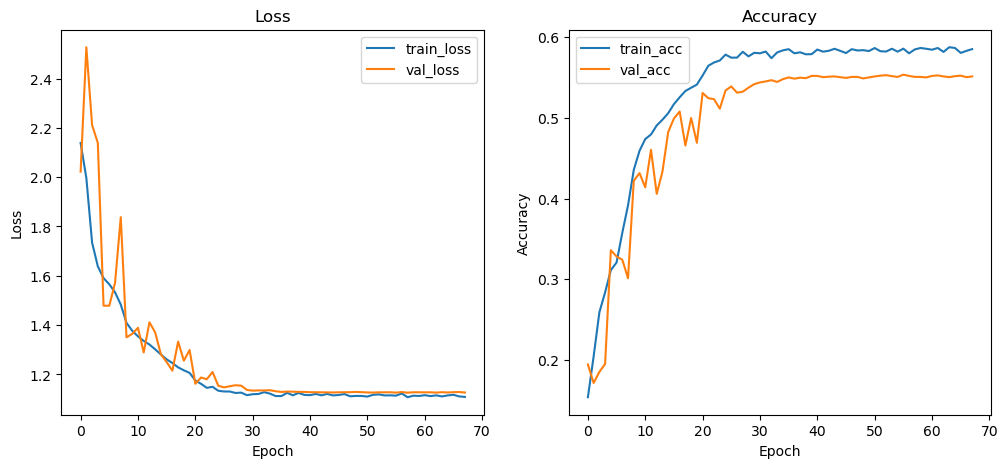

In [17]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [18]:
model = tf.keras.models.load_model(SAVED_MODEL)

In [22]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc*100:.2f}%, Test Loss: {test_loss:.4f}")

454/454 ━━━━━━━━━━━━━━━━━━━━ 34s 76ms/step - accuracy: 0.5644 - loss: 1.6057
Test Accuracy: 56.44%, Test Loss: 1.6057


In [20]:
def report_test_results():
    print("Evaluating on Test Set...")

    loss, accuracy = model.evaluate(test_dataset)

    print(f"Test Accuracy: {accuracy*100:.2f}%")

    print("Generating predictions...")

    predictions = model.predict(test_dataset, verbose=1)

    # Predicted classes
    y_pred_indices = np.argmax(predictions, axis=1)

    # True labels
    y_true_indices = np.concatenate([
        y.numpy() for x, y in test_dataset
    ])

    print(classification_report(
        y_true_indices,
        y_pred_indices,
        target_names=CLASSES
    ))

report_test_results()

Evaluating on Test Set...
454/454 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.5644 - loss: 1.6057
Test Accuracy: 56.44%
Generating predictions...
454/454 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step
              precision    recall  f1-score   support

       anger       0.47      0.47      0.47      1718
    contempt       0.55      0.52      0.53      1312
     disgust       0.37      0.39      0.38      1248
        fear       0.44      0.43      0.44      1664
       happy       0.88      0.79      0.83      2704
     neutral       0.65      0.92      0.76      2368
         sad       0.45      0.32      0.38      1584
    surprise       0.41      0.36      0.38      1920

    accuracy                           0.56     14518
   macro avg       0.53      0.52      0.52     14518
weighted avg       0.56      0.56      0.56     14518



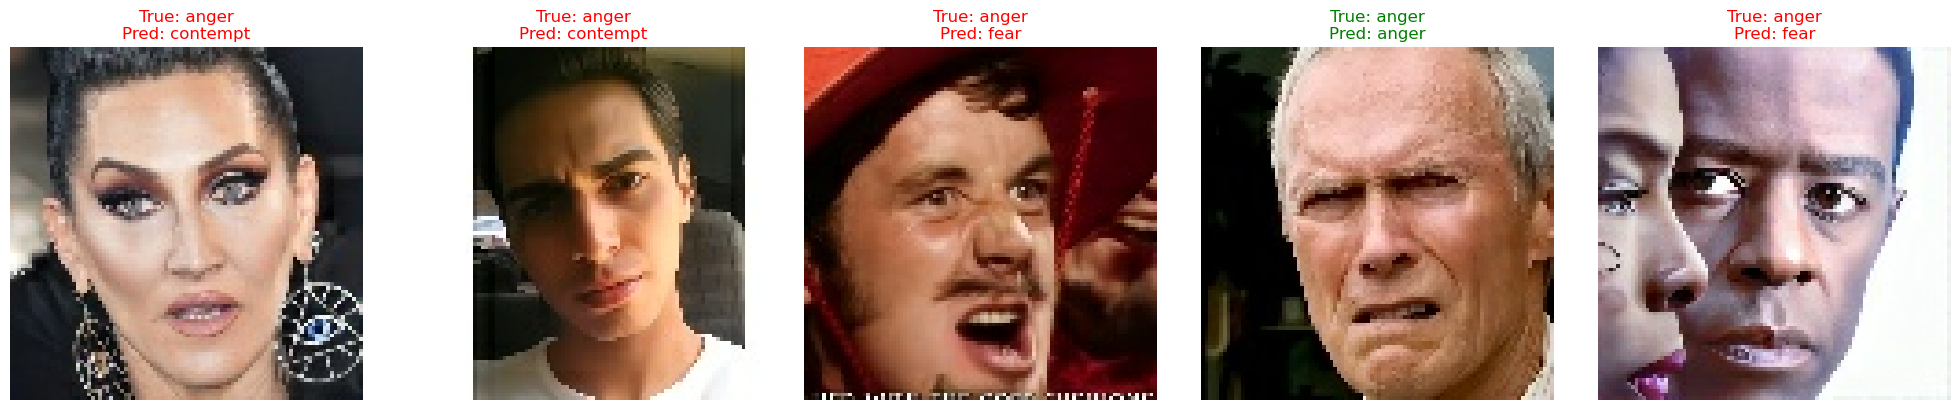

In [21]:
def predict_random_samples():

    # Get one batch
    images, labels = next(iter(test_dataset))

    # Random 5 images
    indices = np.random.choice(len(images), 5, replace=False)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for i, idx in enumerate(indices):

        img = images[i]
        # True label
        true_idx = int(labels[idx])
        true_label = CLASSES[true_idx]

        # Prediction
        pred_prob = model.predict(
            np.expand_dims(img, axis=0),
            verbose=0
        )

        pred_idx = np.argmax(pred_prob)
        pred_label = CLASSES[pred_idx]

        # Plot image
        axes[i].imshow(img.numpy().astype(np.uint8))
        axes[i].axis("off")
        # Color
        color = 'green' if true_idx == pred_idx else 'red'

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label}",
            color=color
        )

    plt.tight_layout()
    plt.show()

predict_random_samples()